https://gamma.app/docs/Time-Series-Analysis-dl7lp24qu0frv6e

# Setup

In [ ]:
# Mount the drive (Google Colab specific)
from google.colab import drive
drive.mount('/content/drive')

In [1]:
%cd /content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting

/content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting


In [62]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# Load the Bitcoin dataset
df = pd.read_csv("bitcoin_price.csv", index_col = "Date", parse_dates = True)
df.head(6)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600


# Time Series Index

In [4]:
# Load the bitcoin price data
df = pd.read_csv("bitcoin_price.csv")
df.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200


In [5]:
# Preview the df information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3392 entries, 0 to 3391
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3392 non-null   object 
 1   Open       3392 non-null   float64
 2   High       3392 non-null   float64
 3   Low        3392 non-null   float64
 4   Close      3392 non-null   float64
 5   Adj Close  3392 non-null   float64
 6   Volume     3392 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 185.6+ KB


In [6]:
# Transform Date column into a datetime object
df["Date"] = pd.to_datetime(df["Date"], format = "%Y-%m-%d")
df.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200


In [7]:
# Set the Date in the index
df.set_index("Date", inplace = True)
df.head(2)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200


In [8]:
# Select a specific day
df.loc["2021-11-09"]

,2021-11-09
Open,6.754973e+04
High,6.853034e+04
Low,6.638206e+04
Close,6.697183e+04
Adj Close,6.697183e+04
Volume,4.235799e+10


In [9]:
# Resampling -> Aggregating the data
df.resample("W").min()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,394.673004,412.425995,384.532013,394.795990,394.795990,21056800
2014-09-28,399.100006,401.016998,374.332001,377.181000,377.181000,15029300
2014-10-05,328.915985,341.800995,289.295990,320.510010,320.510010,21777700
2014-10-12,320.389008,339.247009,302.559998,330.079010,330.079010,13345200
2014-10-19,377.920990,385.477997,368.897003,382.556000,382.556000,5914570
...,...,...,...,...,...,...
2023-12-03,37247.992188,37559.355469,36750.128906,37254.167969,37254.167969,15534035612
2023-12-10,39978.628906,42371.750000,39978.628906,41980.097656,41980.097656,13000481418
2023-12-17,41238.734375,42048.304688,40234.578125,41243.832031,41243.832031,14386729590


# Exploratory Data Analysis

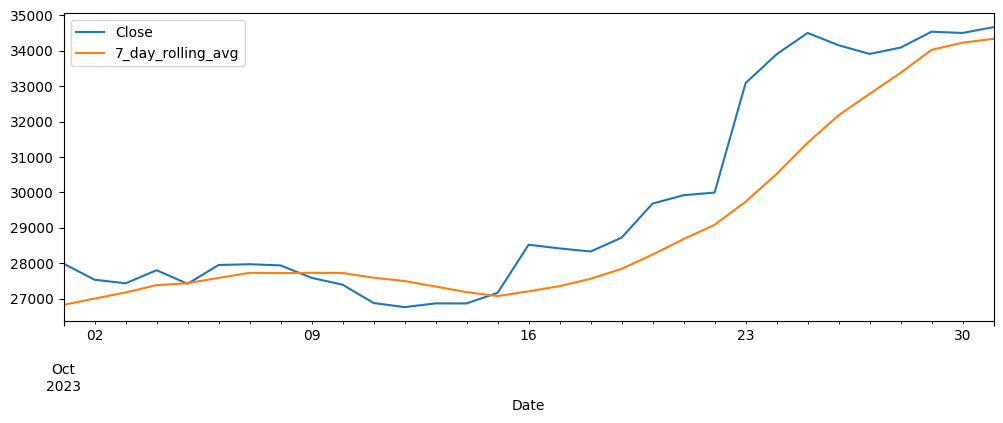

In [10]:
# Rolling Moving averages
df["7_day_rolling_avg"] = df["Close"].rolling(window = 7).mean()

# Plot the Close and Moving average
df[["Close", "7_day_rolling_avg"]].loc["2023-10"].plot(figsize=(12,4))
plt.show()

In [11]:
# Find the month-end date ("ME") with the highest average closing price
df.resample("ME").mean()["Close"].idxmax()

Timestamp('2021-11-30 00:00:00')

In [12]:
# PReview the last 5 rows
df.tail()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg
Date,,,,,,,
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,42520.402344,30026850982,43486.929688
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,43442.855469,25260941032,43457.016183
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,42627.855469,22992093014,43279.688058
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,42099.402344,26000021055,43008.473772
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,42156.902344,16013925945,42782.382254


In [13]:
# Compute the daily percentage returns for Closing Price ((Price t - price t - 1) / Price t-1)
df["daily_returns_100%"] = df['Close'].pct_change() * 100

In [14]:
# Identify any days with more than 10% change
df[abs(df["daily_returns_100%"]) > 10]

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%
Date,,,,,,,,
2014-11-12,367.984985,429.717987,367.984985,423.561005,423.561005,45783200,365.519579,15.193570
2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400,310.171718,-10.776686
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-01-15,176.897003,229.067001,176.897003,209.843994,209.843994,81773504,244.638280,17.821709
...,...,...,...,...,...,...,...,...
2022-09-09,19328.140625,21439.410156,19310.962891,21381.152344,21381.152344,48469528171,19781.450056,10.612188
2022-11-08,20600.671875,20664.607422,17603.544922,18541.271484,18541.271484,118992465607,20409.998326,-10.006132
2022-11-09,18543.761719,18590.458984,15682.692383,15880.780273,15880.780273,102905151606,19798.752093,-14.349022


# Data Visualization

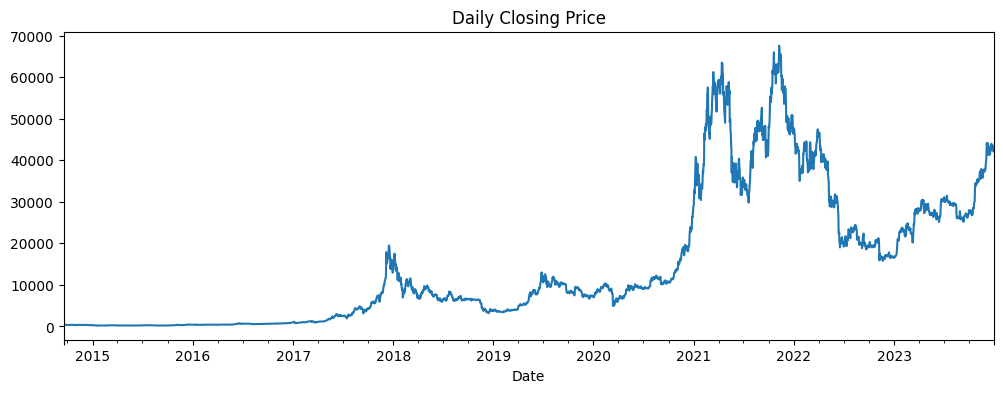

In [15]:
  # Simple plot
  df["Close"].plot(figsize = (12,4), title = "Daily Closing Price")
  plt.show()

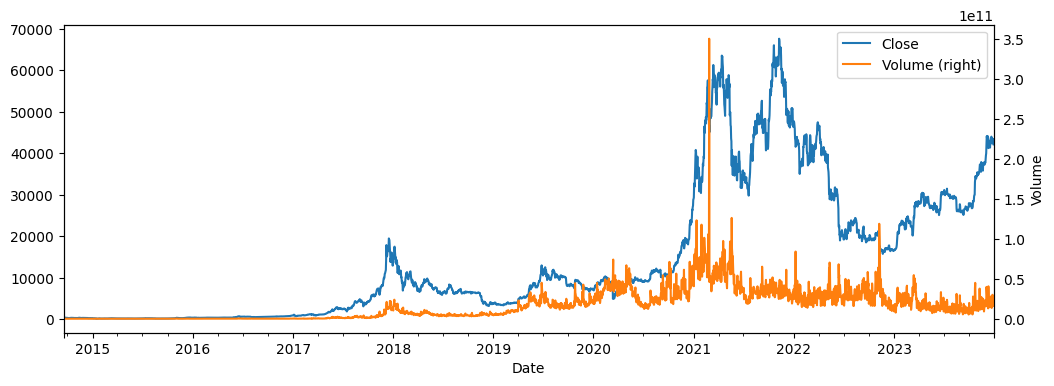

In [16]:
# Plot the Time series against Volume
df[["Close"]].plot(figsize = (12,4), legend = True)
ax = df["Volume"].plot(legend = True, secondary_y = True )
ax.set_ylabel("Volume")
plt.show()

In [17]:
# Correlation
# Pearson Correlation
# Spearman Correlation
print(f"The Pearson Correlation is {df["Close"].corr(df["Volume"]):.2f}")
print(f"The Spearman Correlation is {df["Close"].corr(df["Volume"], method = 'spearman'):.2f}")


The Pearson Correlation is 0.68
The Spearman Correlation is 0.87


# Data Manipulation

In [18]:
# Missing values
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
7_day_rolling_avg,6
daily_returns_100%,1


In [19]:
df.head(9)

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600,NaN,0.835210
2014-09-23,402.092010,441.557007,396.196991,435.790985,435.790985,45099500,417.462572,8.364742
2014-09-24,435.751007,436.112000,421.131989,423.204987,423.204987,30627700,412.586997,-2.888081
2014-09-25,423.156006,423.519989,409.467987,411.574005,411.574005,26814400,410.748997,-2.748309


In [20]:
# Backward filling - Take the next non-null value
df['daily_returns_100%'] = df['daily_returns_100%'].bfill()
df.head(2)

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,-7.192558
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558


In [21]:
# Interpolate
df['7_day_rolling_avg'] = df['7_day_rolling_avg'].bfill() # ffill
df.head(9)

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,417.462572,-7.192558
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,417.462572,-7.192558
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,417.462572,-6.984265
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,417.462572,3.573492
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,417.462572,-2.465854
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600,417.462572,0.835210
2014-09-23,402.092010,441.557007,396.196991,435.790985,435.790985,45099500,417.462572,8.364742
2014-09-24,435.751007,436.112000,421.131989,423.204987,423.204987,30627700,412.586997,-2.888081
2014-09-25,423.156006,423.519989,409.467987,411.574005,411.574005,26814400,410.748997,-2.748309


In [24]:
# Check the information in the index
df.index.year

Index([2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014,
       ...
       2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023],
      dtype='int32', name='Date', length=3392)

In [29]:
# Extract the time components from the index for potential feature engineering
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['day_name'] = df.index.day_name()
df['weekday'] = df.index.weekday
df['quarter'] = df.index.quarter

# Create a variable for weekend
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday'])

# Create a variable for weekend in summer
df['is_weekend_summer'] = df['is_weekend'] & df['month'].isin([6,7,8])

df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%,year,month,day,day_of_week,day_name,weekday,quarter,is_weekend,is_weekend_summer
Date,,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,417.462572,-7.192558,2014,9,17,2,Wednesday,2,3,False,False
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,417.462572,-7.192558,2014,9,18,3,Thursday,3,3,False,False
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,417.462572,-6.984265,2014,9,19,4,Friday,4,3,False,False
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,417.462572,3.573492,2014,9,20,5,Saturday,5,3,True,False
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,417.462572,-2.465854,2014,9,21,6,Sunday,6,3,True,False


In [31]:
# Shift - Creates lagged variables
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,daily_returns_100%,year,month,day,day_of_week,day_name,weekday,quarter,is_weekend,is_weekend_summer,Close_lag1,Close_lag2
Date,,,,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,417.462572,-7.192558,2014,9,17,2,Wednesday,2,3,False,False,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,417.462572,-7.192558,2014,9,18,3,Thursday,3,3,False,False,457.334015,NaN
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,417.462572,-6.984265,2014,9,19,4,Friday,4,3,False,False,424.440002,457.334015
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,417.462572,3.573492,2014,9,20,5,Saturday,5,3,True,False,394.795990,424.440002
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,417.462572,-2.465854,2014,9,21,6,Sunday,6,3,True,False,408.903992,394.795990


# Seasonality

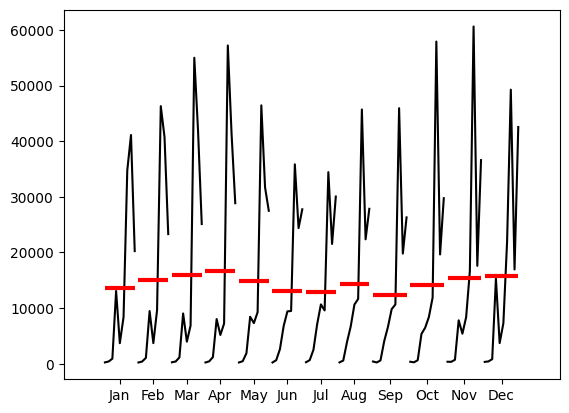

In [35]:
# Perform the month_plot
month_plot(df["Close"].resample("ME").mean())
plt.show()

/tmp/ipykernel_1994/2882054616.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df["Close"].resample("Q").mean())


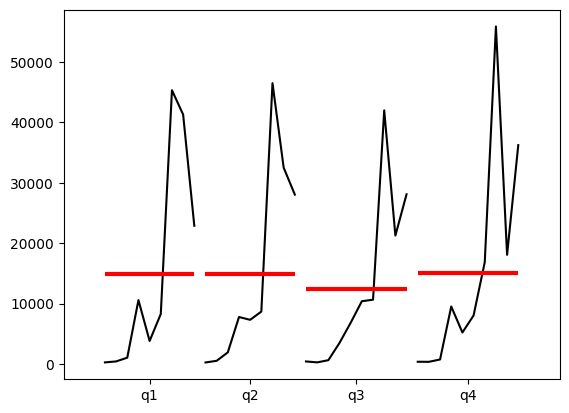

In [36]:
# Perform the Quarter plot
quarter_plot(df["Close"].resample("Q").mean())
plt.show()

In [39]:
# Load the second dataset
df_choco = pd.read_csv("choco_monthly_revenue.csv", index_col = "Month with Year", parse_dates = True)
df_choco.head()

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461


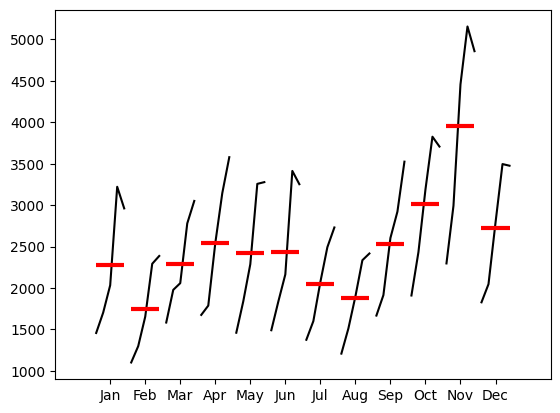

In [41]:
# Plot the month_plot with the new dataset
month_plot(df_choco["revenue"])
plt.show()

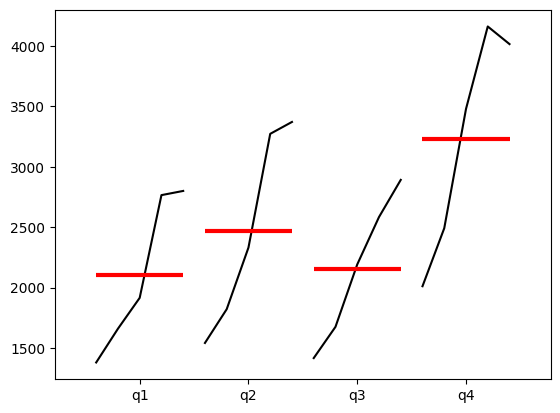

In [45]:
# Perform the quarterly plot
quarter_plot(df_choco["revenue"].resample("QE").mean())
plt.show()

<Axes: xlabel='Date'>

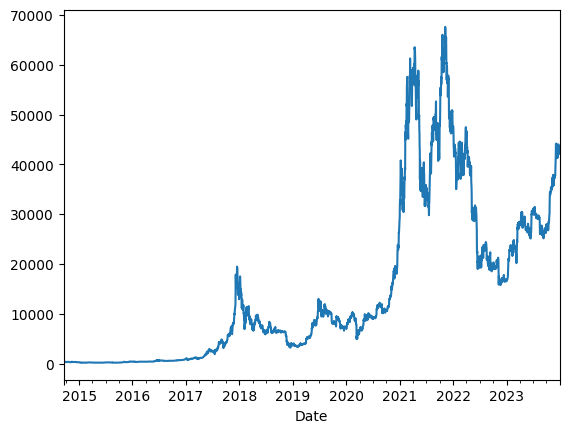

In [47]:
df['Close'].plot()

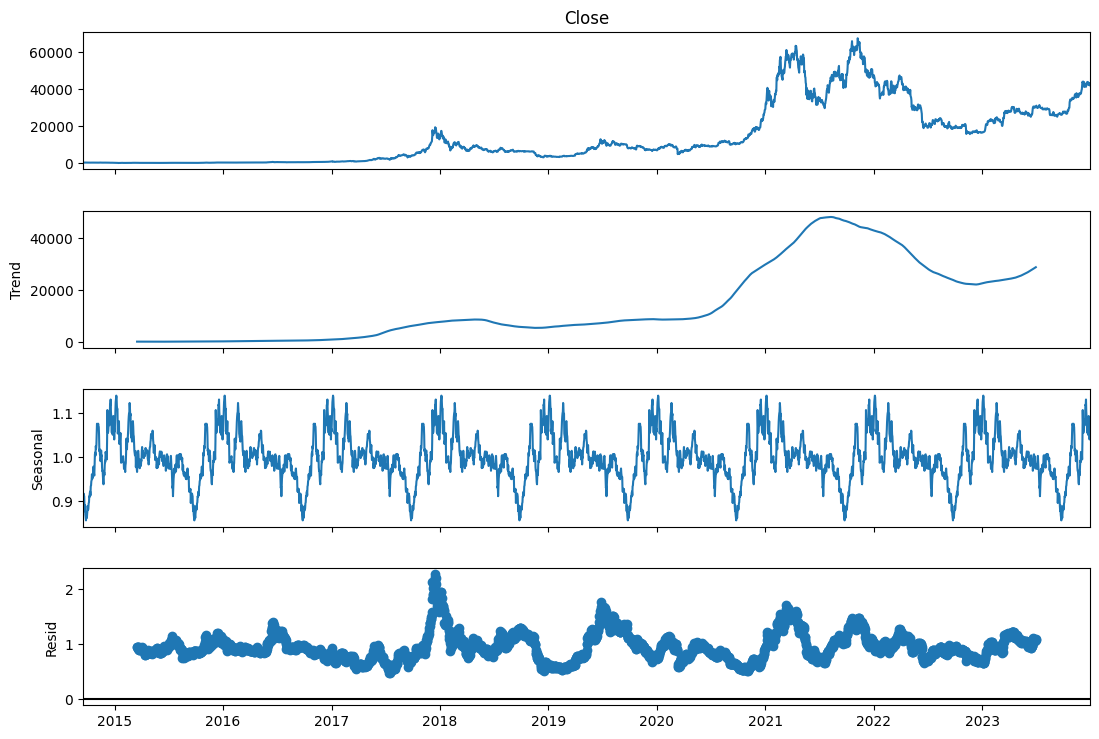

In [53]:
# Perform seasonal decomposition
decomposition = seasonal_decompose(
    df["Close"],
    model = "multiplicative",
    period = 365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

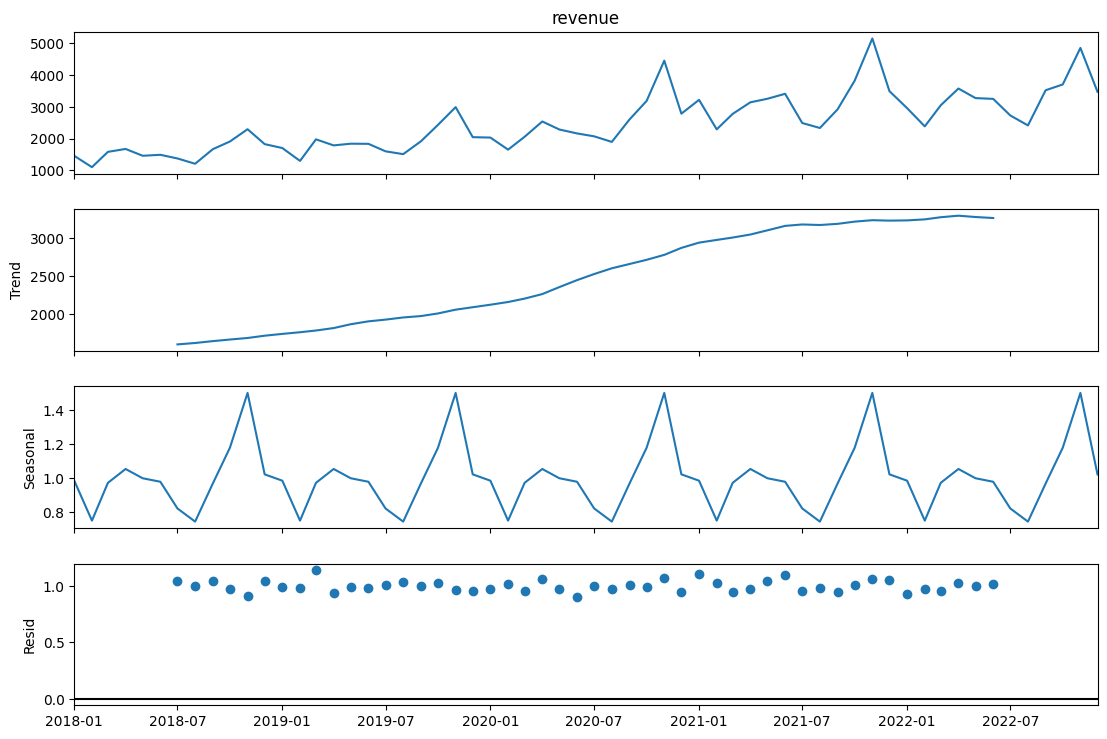

In [55]:
# Perform the seasonal decomposition for df_choco
decomposition = seasonal_decompose(
    df_choco["revenue"],
    model = "mul",
    period = 12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# plotting ACF

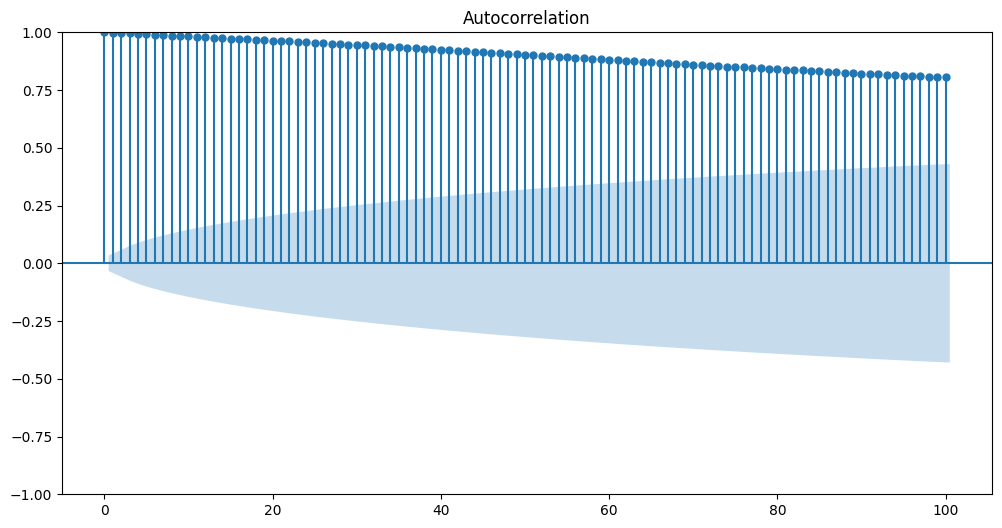

In [59]:
# Plot the ACF with the Closing prices
fig, ax = plt.subplots(figsize = (12,6))
plot_acf(df["Close"], ax = ax, lags = 100)
plt.show()

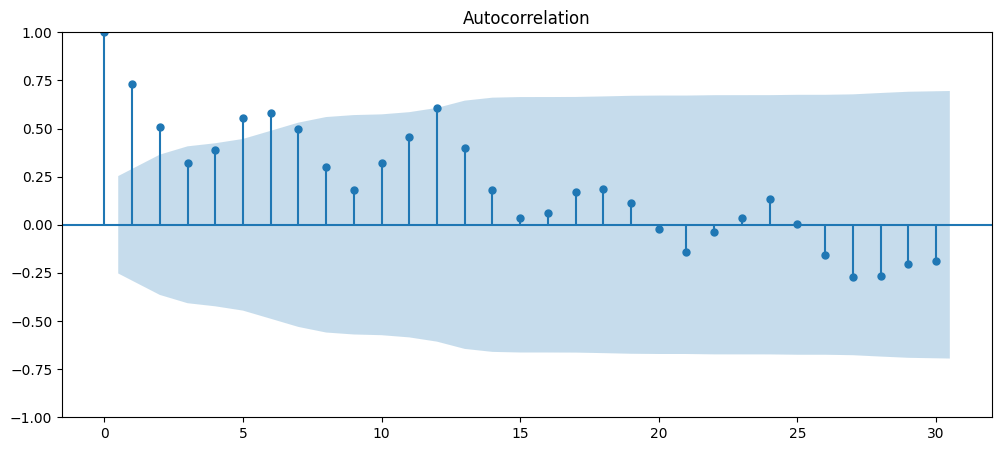

In [61]:
# Plot the ACF for the df_choco and revenue columns
fig, ax = plt.subplots(figsize = (12,5))
plot_acf(df_choco["revenue"], ax = ax, lags = 30)
plt.show()

# PACF

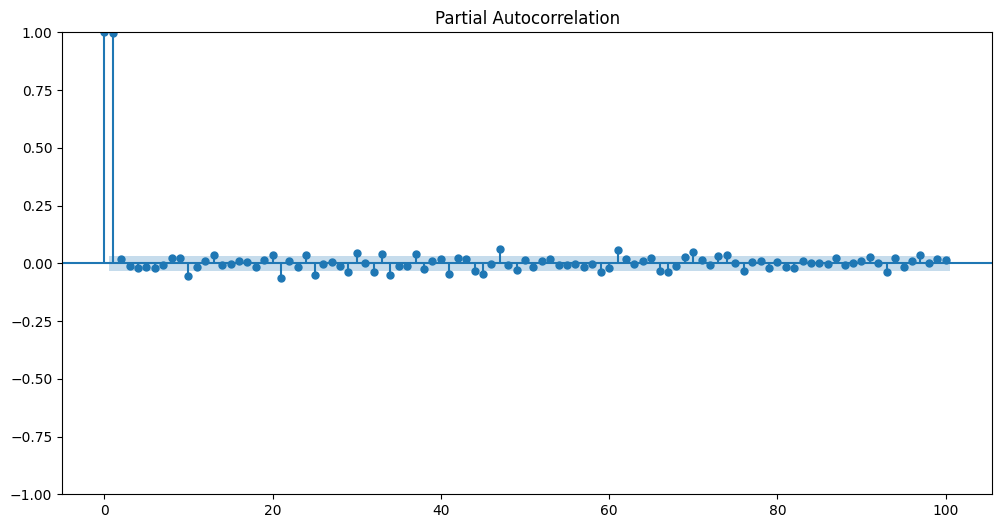

In [63]:
# Plot the PACF
fig, ax = plt.subplots(figsize = (12,6))
plot_pacf(df["Close"], ax = ax, lags = 100)
plt.show()

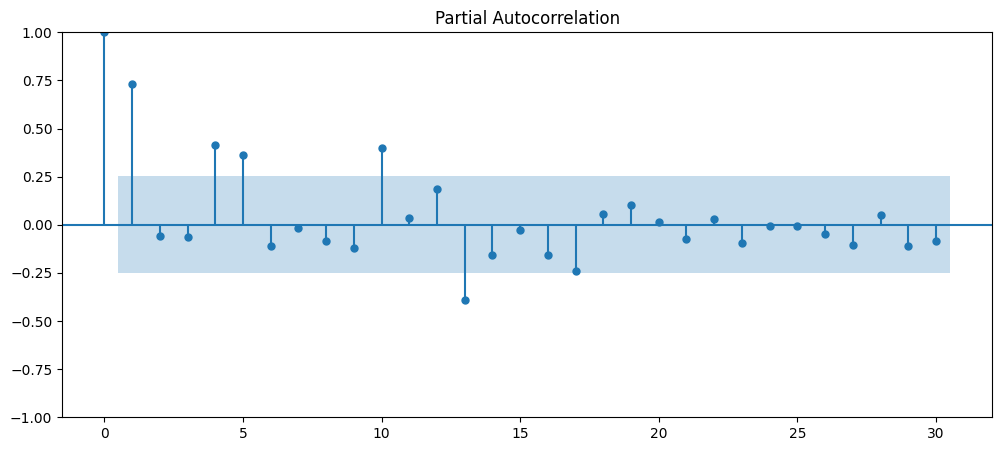

In [65]:
# Plot the PACF with revenue
fig, ax = plt.subplots(figsize = (12,5))
plot_pacf(df_choco["revenue"], ax = ax, lags = 30)
plt.show()